# Обязательное ДЗ№8. Решить задачу сегментации кружочков.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else "cpu"

learning_rate = 3e-4
batch_size = 32
epochs = 30

device

device(type='cuda')

In [2]:
from dataset import DataGenerator
import os

x_size, y_size = 572, 572

train_samples = batch_size * 20
val_samples = batch_size * 4
test_samples = batch_size * 2

if not os.path.exists("./data/train.npz"):
    os.makedirs("./data", exist_ok=True)
    data_generator = DataGenerator()

    data_generator.generate_data(x_size, y_size, train_samples)
    data_generator.save_data("./data/train.npz")

    data_generator.generate_data(x_size, y_size, val_samples)
    data_generator.save_data("./data/val.npz")

    data_generator.generate_data(x_size, y_size, test_samples)
    data_generator.save_data("./data/test.npz")
else:
    print("Data already exists")

Data already exists


In [3]:
from dataset import TrainDataset, TestDataset
from torch.utils.data import DataLoader
import os

train_dataset = TrainDataset("./data/train.npz")
val_dataset = TrainDataset("./data/val.npz")
test_dataset = TestDataset("./data/test.npz")

is_cuda = (hasattr(device, "type") and device.type == "cuda") or (str(device) == "cuda")
num_workers = min(8, (os.cpu_count() or 2) - 1)
num_workers = max(0, num_workers)

common_loader_kwargs = dict(
    batch_size=batch_size,
    num_workers=num_workers,
    pin_memory=is_cuda,
    persistent_workers=(num_workers > 0),
)

train_loader = DataLoader(train_dataset, shuffle=True, **common_loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **common_loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **common_loader_kwargs)

In [ ]:
from unet import UNet
from trainer import Trainer
import torch.nn as nn
import torch.optim as optim

model = UNet(num_classes=3, in_channels=3)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

trainer = Trainer(model, loss_fn, optimizer, device, epoch_amount=epochs)

In [5]:
# trainer.fit(train_loader, val_loader)

In [6]:
# trainer.save("./data/model.pth")

In [7]:
trainer.load("./data/model.pth")

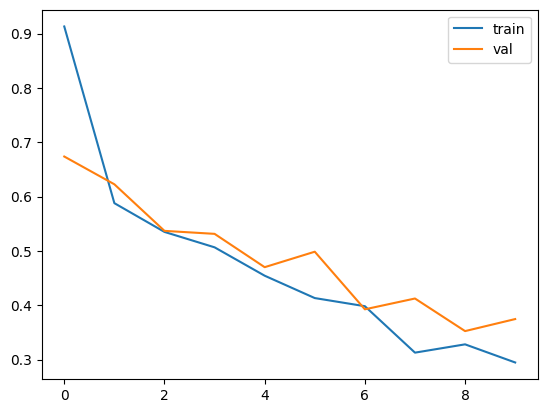

In [8]:
plt.plot(trainer.train_loss, label="train")
plt.plot(trainer.val_loss, label="val")
plt.legend()
plt.show()

In [10]:
predictions = trainer.predict(test_loader)

In [11]:
predictions = predictions.cpu().numpy()
y_pred = np.argmax(predictions, axis=1)

loaded = np.load("./data/test.npz")
y_true = np.argmax(loaded["labels"], axis=-1)


def mean_dice_score(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int = 3, eps: float = 1e-8) -> float:
    """Mean Dice over classes for integer label maps (H, W) or stacks (N, H, W)."""
    dices = []
    for c in range(num_classes):
        t = y_true == c
        p = y_pred == c
        inter = np.logical_and(t, p).sum(dtype=np.float64)
        denom = t.sum(dtype=np.float64) + p.sum(dtype=np.float64)
        dices.append((2.0 * inter + eps) / (denom + eps))
    return float(np.mean(dices))


score = mean_dice_score(y_true, y_pred)
print(f"Mean Dice score: {score:.4f}")

Mean Dice score: 0.5584


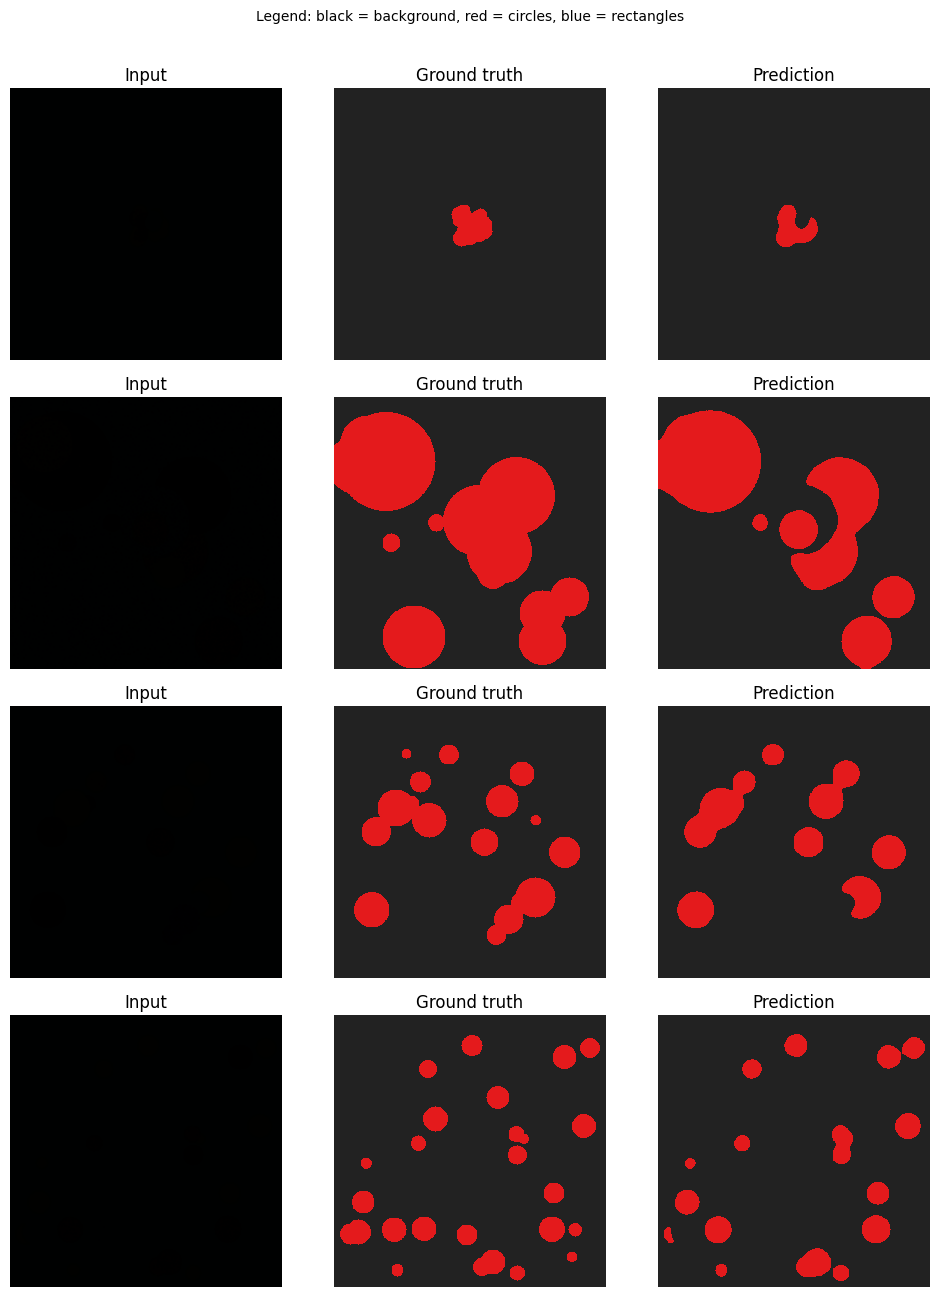

In [12]:
from matplotlib.colors import ListedColormap

_label_cmap = ListedColormap(["#222222", "#e41a1c", "#377eb8"])
_n_show = min(4, len(y_true))
fig, axes = plt.subplots(_n_show, 3, figsize=(10, 3.2 * _n_show))
if _n_show == 1:
    axes = np.asarray([axes])

for row, i in enumerate(range(_n_show)):
    img = loaded["data"][i]
    if img.dtype != np.uint8:
        img = np.clip(img, 0, 255).astype(np.uint8)

    axes[row, 0].imshow(img)
    axes[row, 0].set_title("Input")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(y_true[i], cmap=_label_cmap, vmin=0, vmax=2, interpolation="nearest")
    axes[row, 1].set_title("Ground truth")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(y_pred[i], cmap=_label_cmap, vmin=0, vmax=2, interpolation="nearest")
    axes[row, 2].set_title("Prediction")
    axes[row, 2].axis("off")

plt.suptitle("Legend: black = background, red = circles, blue = rectangles", y=1.01, fontsize=10)
plt.tight_layout()
plt.show()